# ⏱️ 시계열 데이터 구조 — 핵심 개념 복습 노트

**학습 범위**
- 20_01 시계열 데이터의 이해와 구조
- 20_02 날짜·시간 인덱스 만들기와 시간 집계

> 강의자료를 기준으로 나중에 빠르게 복습할 수 있도록  
> **목차 → 한눈에 보는 코드 → 개념 → 원리 → 코드 → 주의점 → 셀프 체크 → 실습** 순서로 정리했습니다.

In [ ]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

## 1. 📌 한 줄 요약 (Executive Summary)

시계열 데이터는 **시간 또는 작동 순서가 의미를 가지는 데이터**이며, 분석의 핵심은 값 자체보다 **시간에 따라 어떻게 변하는가**를 보는 것입니다.

이번 단원에서는 다음 흐름을 익힙니다.

```text
시계열 이해
→ timestamp / cycle 구분
→ 데이터 구조 확인
→ 문자열 날짜를 datetime으로 변환
→ 시간 인덱스 설정
→ 기간 선택
→ resample로 시간 집계
→ 결측/보간
→ 그래프로 추세 확인
```

## 2. 🗂️ 핵심 목차 및 개요

- **A. 시계열 데이터의 기본**
  - 순서가 중요한 데이터
  - 시간과 값의 짝
  - 단일 / 다변량 시계열
  - 추세 · 변동성 · 이상 징후
- **B. 두 가지 시간 축**
  - timestamp 기반
  - cycle 기반
  - 두 방식의 공통점과 차이
  - 예지보전에서의 활용
- **C. C-MAPSS 데이터 구조**
  - `unit_nr`
  - `time_cycles`
  - `setting_1~3`
  - `s_1~s_21`
  - 한 엔진 필터링과 cycle 정렬
  - 센서 범위·결측·유효 센서 선별
- **D. 날짜 데이터 만들기**
  - 문자열 날짜의 문제
  - `pd.to_datetime()`
  - `format`
  - `errors="coerce"`
  - `.dt.year`, `.dt.month`, `.dt.day`, `.dt.hour`
- **E. 시간 인덱스**
  - `DatetimeIndex`
  - `set_index()`
  - `sort_index()`
  - `.loc[]`
  - 부분 문자열 인덱싱
  - 기간 슬라이싱
- **F. 시간 단위 집계**
  - `resample()`
  - 다운샘플링 / 업샘플링
  - 빈도 문자열 `h`, `D`, `min`, `6h`
  - `.mean()`, `.max()`, `.min()`, `.sum()`
  - `asfreq()`
- **G. 결측과 보간**
  - `ffill`
  - `bfill`
  - `interpolate`
  - 업샘플링으로 생긴 결측
- **H. 전체 분석 흐름**
  - 준비 → 선택 → 집계 → 시각화

## 3. 💻 한눈에 보는 코드 정리

| 코드 | 무엇을 하는가 | 꼭 기억할 포인트 |
|---|---|---|
| `pd.read_csv(...)` | CSV 읽기 | 읽은 뒤 `head()`로 확인 |
| `df.shape` | 행·열 개수 | 속성이라 괄호 없음 |
| `df.columns` | 컬럼 이름 | 속성이라 괄호 없음 |
| `df.head()` | 앞 5행 확인 | 값 모양 확인 |
| `df.info()` | 자료형·결측 확인 | 데이터 건강검진 |
| `df.describe()` | 평균·표준편차·범위 | 센서 스케일 확인 |
| `df.isna().sum()` | 결측 개수 | 분석 전에 확인 |
| `df[df["unit_nr"] == 1]` | 특정 엔진 선택 | 여러 엔진을 섞지 않기 |
| `.sort_values("time_cycles")` | cycle 순 정렬 | cycle 기반 시계열 필수 |
| `pd.to_datetime(...)` | 문자열 → 시간 | 시간 기능의 출발점 |
| `format="%Y-%m-%d"` | 날짜 형식 지정 | 자동 인식이 실패할 때 |
| `errors="coerce"` | 잘못된 날짜를 NaT 처리 | 오류값 점검에 유용 |
| `.dt.year` | 연도 추출 | datetime 변환 후 사용 |
| `.dt.month` | 월 추출 | 월별 패턴 분석 |
| `.dt.day` | 일 추출 | 일자 분석 |
| `.dt.hour` | 시 추출 | 시간대 분석 |
| `df.set_index("timestamp")` | 시간 인덱스 설정 | 결과를 다시 `df`에 담기 |
| `df.sort_index()` | 시간순 정렬 | 기간 슬라이싱 전에 |
| `df.loc["2024-03-01"]` | 하루 선택 | 그날 전체 행 |
| `df.loc["2024-03"]` | 한 달 선택 | 부분 문자열 인덱싱 |
| `df.loc["2024-03-01":"2024-03-03"]` | 기간 선택 | 끝 날짜 포함 |
| `.resample("D").mean()` | 일별 평균 | 큰 흐름 보기 |
| `.resample("6h").max()` | 6시간 최댓값 | 위험 스파이크 점검 |
| `.asfreq("D")` | 간격 재배치 | 누락 시점 확인 |
| `.interpolate()` | 결측 보간 | 추정값이라는 점 주의 |
| `.ffill()` | 앞 값으로 채움 | 상태가 유지되는 값에 적합 |
| `plt.plot(...)` | 시계열 선 그래프 | 방향·떨림·튐 확인 |

# 4. 💡 시계열 데이터란?

## 4-1. 순서가 중요한 데이터

### 개념 정의
**행의 순서를 섞으면 중요한 정보가 사라지는 데이터**가 시계열의 출발점입니다.

### 예
학생 키 목록은 줄을 섞어도 평균이나 분포가 그대로입니다.

반면 설비 온도가:

```text
09:00 → 80.1
09:01 → 80.3
09:02 → 80.6
```

이라면 순서를 섞는 순간 **“온도가 점점 올라가고 있었다”**는 정보가 사라집니다.

### 핵심 질문
> 이 데이터는 행의 순서가 의미를 가지는가?

그리고 그 순서가 시간이라면 시계열 분석으로 접근합니다.

## 4-2. 시계열 데이터의 정의

시계열 데이터는:

> **시간 순서대로 기록되고, 모든 값에 시간 정보가 함께 붙은 데이터**

입니다.

즉:

```text
시간 정보 + 측정값 = 시계열
```

예:
- 날씨
- 주가
- 미세먼지
- 심전도
- 설비 센서

## 4-3. 순서 무관 vs 순서 중요

| 구분 | 순서 무관 | 순서 중요 |
|---|---|---|
| 예시 | 학생 키 | 설비 온도 |
| 섞으면 | 의미 유지 | 정보 손실 |
| 핵심 질문 | 값이 얼마인가 | 어떻게 변화하는가 |
| 분석 초점 | 평균·분포 | 추세·변동 |

설비 데이터는 보통 오른쪽에 해당합니다.

## 4-4. 단일 시계열과 다변량 시계열

### 단일 시계열
시간축 + 값 1개

예:
```text
시간 + 온도
```

### 다변량 시계열
시간축 + 여러 센서

예:
```text
시간 + 온도 + 압력 + 진동 + 전류
```

설비 데이터는 센서가 여러 개이므로 대부분 **다변량 시계열**입니다.

강의자료의 C-MAPSS는 센서가 21개인 다변량 시계열입니다.

# 5. 📈 시계열 분석에서 보는 3가지 신호

## 5-1. 추세 (Trend)

### 개념
값이 시간에 따라 **전체적으로 어느 방향으로 이동하는지** 보는 것입니다.

- 우상향 → 상승 추세
- 우하향 → 하락 추세

### 설비 분석 의미
엔진 온도가 서서히 올라가는 흐름은 부품 마모의 초기 신호일 수 있습니다.

## 5-2. 변동성 (Volatility)

### 개념
값이 위아래로 **얼마나 크게 출렁이는지**를 의미합니다.

- 잔잔함 → 안정적
- 흔들림 증가 → 변동성 증가

설비 고장이 가까워질수록 값의 출렁임이 커지는 경우가 있습니다.

## 5-3. 이상 징후 (Anomaly)

### 개념
평소 패턴에서 크게 벗어난 갑작스러운 값입니다.

그래프에서는 보통 한 점만 위 또는 아래로 튀는 **스파이크**처럼 보입니다.

### 중요
이상치 점 하나가 곧 고장이라는 뜻은 아닙니다.

강의자료의 판단 기준은:

> **평소 같은 조건의 패턴과 다른가?**

## 5-4. 정상과 이상 패턴 한눈에

| 패턴 | 그래프 모습 | 의미 |
|---|---|---|
| 정상 | 잔잔한 가로 흐름 | 일정 수준 근처 |
| 추세 이상 | 지속적 우상향/우하향 | 값이 한 방향으로 이동 |
| 변동성 이상 | 출렁임이 점점 커짐 | 안정성 저하 |
| 이상치 | 한 점만 뾰족하게 튐 | 순간 이상 후보 |

시계열 그래프를 보면 **방향 → 떨림 → 튐** 순서로 확인하면 좋습니다.

# 6. ⏰ 두 가지 시계열 방식 — timestamp와 cycle

## 6-1. timestamp 기반 시계열

### 개념
실제 날짜·시각이 시간축으로 붙은 방식입니다.

예:
```text
2024-03-01 09:00:00
2024-03-01 09:01:00
2024-03-01 09:02:00
```

### 장점
- “언제”가 명확
- 시간별·일별·월별 집계 가능
- 시간대별 운영 패턴 분석 가능

### 대표 활용
- 공장
- 발전소
- 건물 에너지
- 실시간 모니터링

## 6-2. cycle 기반 시계열

### 개념
실제 날짜 대신 **몇 번째 작동인가**를 시간축으로 쓰는 방식입니다.

예:
```text
1 cycle
2 cycle
3 cycle
...
```

NASA C-MAPSS가 이 방식입니다.

### 핵심
cycle은 단위가 초·분·시가 아닐 뿐, **순서가 살아 있기 때문에 시계열**입니다.

## 6-3. 왜 cycle을 사용하는가?

설비의 마모는 달력 날짜보다 **얼마나 많이 작동했는가**에 더 밀접할 수 있습니다.

자동차의 사용 정도를 날짜보다 **주행거리**로 판단하는 것과 같은 발상입니다.

### 장점
- 가동 빈도가 다른 설비 비교
- 작동 횟수 기준 열화 분석
- 남은 수명(RUL) 분석에 적합

## 6-4. timestamp와 cycle 비교

| 구분 | timestamp | cycle |
|---|---|---|
| 시간축 | 날짜·시각 | 작동 번호 |
| 예 | `2024-03-01 09:00` | `137번째` |
| 대표 분석 | 시·일 집계 | 이동평균·열화 흐름 |
| 대표 데이터 | 공장 센서 | C-MAPSS |
| 대표 질문 | 지금 정상인가? | 몇 번 더 쓸 수 있나? |

둘 다 **순서가 살아 있는 시계열**이고, 추세·변동·이상을 찾는 목적은 같습니다.

## 6-5. 예지보전에서의 활용

| 목적 | 자연스러운 방식 | 대표 질문 |
|---|---|---|
| 실시간 감시 | timestamp | 지금 정상인가? |
| 운영 분석 | timestamp | 시간대 차이가 있는가? |
| 수명 예측 | cycle | 몇 번 더 사용할 수 있나? |
| 설비 비교 | cycle | 어느 설비가 더 많이 닳았나? |

좋고 나쁨의 문제가 아니라 **답하려는 질문에 따라 시간축을 선택**합니다.

# 7. 🛠️ 정비 방식 3가지

강의자료는 시계열 분석의 최종 목적을 **예지보전(PdM)**과 연결합니다.

### 1. 사후 정비
고장 난 뒤 수리

### 2. 예방 정비
일정 주기로 미리 점검·교체

### 3. 예지보전
센서 데이터에서 이상 신호를 읽고 **고장 직전에 필요한 정비**

이번 단원은 모델 예측까지 가기보다  
**데이터에서 추세·변동성·이상 징후를 읽는 눈**을 만드는 단계입니다.

# 8. ✈️ C-MAPSS 데이터 구조

## 8-1. C-MAPSS란?

NASA가 시뮬레이션으로 만든 **엔진 고장 예지보전 표준 데이터셋**입니다.

핵심 특징:
- 정상 상태부터 고장까지의 전 과정 포함
- cycle 증가에 따라 점진적 열화
- 센서 잡음과 엔진별 차이 포함
- 추세·변동성 학습에 적합

강의자료에서는 FD001 교육 샘플을 사용합니다.

## 8-2. FD001 컬럼 구조

총 26개 열을 네 묶음으로 이해하면 쉽습니다.

| 묶음 | 컬럼 | 의미 |
|---|---|---|
| 엔진 번호 | `unit_nr` | 어느 엔진의 기록인가 |
| 작동 cycle | `time_cycles` | 몇 번째 작동인가 |
| 운전 설정 | `setting_1~3` | 작동 조건 |
| 센서값 | `s_1~s_21` | 온도·압력 등 21개 센서 |

강의자료 예:
- `s_4`, `s_11` → 상승 경향
- `s_7`, `s_20` → 하락 경향

## 8-3. 데이터 읽기 기본 흐름

```text
열기 → 살펴보기 → 계산 → 그래프
```

pandas에서는 이 흐름을 반복합니다.

In [ ]:
import pandas as pd

# 강의자료의 C-MAPSS 샘플 파일명
df = pd.read_csv("cmapss_fd001_sample.csv")

# 파일을 연 직후 잘 읽혔는지 확인
print(df.head())

### ⚠️ 실행 전 확인
위 코드는 강의자료에서 사용한 샘플 CSV가 같은 작업 폴더에 있어야 실행됩니다.

자주 생기는 오류:
- 파일명 오타
- 파일이 다른 폴더에 있음

# 9. 🔍 데이터 처음 받았을 때 확인하는 3가지 질문

## 질문 1. 얼마나 큰가?
```python
df.shape
df.columns
```

## 질문 2. 어떻게 생겼나?
```python
df.head()
df.info()
```

## 질문 3. 값들이 정상인가?
```python
df.describe()
df.isna().sum()
```

강의자료의 권장 습관은 **크기 → 구조 → 상태** 순으로 보는 것입니다.

In [ ]:
# 1. 크기
print(df.shape)
print(df.columns)

# 2. 구조
print(df.head())
df.info()

# 3. 상태
print(df.describe())
print(df.isna().sum())

## 9-1. 메서드와 속성 구분

| 코드 | 종류 | 괄호 |
|---|---|---|
| `df.head()` | 메서드 | O |
| `df.info()` | 메서드 | O |
| `df.describe()` | 메서드 | O |
| `df.shape` | 속성 | X |
| `df.columns` | 속성 | X |

`shape()`처럼 쓰지 않도록 주의하세요.

# 10. 🚗 한 엔진을 cycle 순서로 보기

시계열 분석에서는 여러 엔진을 한꺼번에 섞기보다  
**엔진 한 대를 선택하고 시간 순서로 정렬**하는 것이 기본입니다.

### 핵심 2단계
1. 대상 선택
2. 시간 순 정렬

In [ ]:
# 1번 엔진만 선택
engine1 = df[df["unit_nr"] == 1]

# cycle 순으로 정렬
engine1 = engine1.sort_values("time_cycles")

print(engine1.head())

### 왜 정렬이 필요한가?
시계열 그래프에서 행 순서가 뒤섞이면 추세가 깨집니다.

따라서:

> **보기 전에 정렬한다**

를 습관처럼 기억하면 좋습니다.

# 11. 📏 센서값의 범위와 스케일

센서마다 물리량이 달라 값의 크기가 크게 다릅니다.

강의자료 예:
- `s_2` → 약 640
- `s_4` → 약 1400
- `s_9` → 9000 이상
- `s_15` → 약 8

### 문제
9000짜리 센서와 8짜리 센서를 같은 축에 그리면  
작은 센서는 거의 바닥에 붙어 보입니다.

### 기본 대응
1. `describe()`로 범위를 먼저 확인
2. 단위가 크게 다른 센서는 따로 그리기
3. 이후 필요하면 정규화·표준화

In [ ]:
# 센서별 평균, 표준편차, 최소, 최대 확인
print(
    df[["s_2", "s_4", "s_9", "s_15"]].describe()
)

# 12. 🧩 결측치·이상값 점검

## 12-1. 결측치

센서 중단이나 통신 오류로 값이 비어 있을 수 있습니다.

시계열에서는 값 하나가 비면 **흐름 자체가 끊기기 때문에** 더 중요합니다.

```python
df.isna().sum()
```

으로 먼저 확인합니다.

In [ ]:
# 각 열의 결측치 개수
print(df.isna().sum())

# 값의 범위와 이상값 후보 점검
print(df.describe())

## 12-2. 분석에 쓸 센서 고르기

강의자료의 기본 원칙:

> 거의 안 변하는 센서는 빼고, 변화가 보이는 센서를 사용한다.

예:
- `s_1` → 항상 약 518.67 → 제외 후보
- `s_5` → 항상 약 14.62 → 제외 후보
- `s_4` → 상승 추세 → 활용
- `s_11` → 점진 상승 → 활용

### 선별 방법
1. 표준편차 확인
2. 첫 cycle과 마지막 cycle 비교
3. 방향이 일관적인지도 함께 확인

In [ ]:
# 센서 표준편차 비교
sensor_cols = [c for c in df.columns if c.startswith("s_")]

sensor_std = df[sensor_cols].std().sort_values()

print(sensor_std.head())
print(sensor_std.tail())

### 주의
표준편차가 작더라도 **한 방향으로 꾸준히 변하는 센서**는 좋은 열화 신호일 수 있습니다.

즉, 표준편차 하나만으로 판단하지 말고 **추세 방향도 같이 확인**합니다.

# 13. 📉 시계열 그래프 읽는 법

시계열 그래프는 보통:

- x축 → 시간 또는 cycle
- y축 → 센서값

입니다.

그래프를 그린 뒤 **방향 → 떨림 → 튐** 순으로 확인합니다.

In [ ]:
import matplotlib.pyplot as plt

engine1 = df[df["unit_nr"] == 1].sort_values("time_cycles")

plt.figure(figsize=(10, 4))

plt.plot(
    engine1["time_cycles"],
    engine1["s_4"]
)

plt.title("1번 엔진 s_4 변화")
plt.xlabel("cycle")
plt.ylabel("s_4")

plt.show()

## 13-1. 세로축에 속지 않기

그래프가 화면 전체를 크게 출렁여도 실제 값 차이는 작을 수 있습니다.

예:
```text
1399 ~ 1419
```

범위 안에서 화면을 가득 쓰면 변화가 매우 커 보이지만 실제 폭은 약 20입니다.

그래프 모양과 함께 **축의 숫자 범위**를 반드시 읽어야 합니다.

# 14. 📅 문자열 날짜를 진짜 시간으로 바꾸기

## 14-1. 문자열 날짜의 문제

CSV에서:

```text
2024-03-01 09:00:00
```

처럼 보이더라도 pandas는 처음에 이를 `object` 문자열로 읽을 수 있습니다.

문자열 상태에서는:
- 날짜 계산
- 기간 선택
- 시간 집계
- 시간 인덱싱

을 제대로 사용할 수 없습니다.

따라서 먼저 **진짜 datetime 자료형**으로 바꿔야 합니다.

## 14-2. `pd.to_datetime()` — 시간 분석의 관문

`pd.to_datetime()`은 날짜처럼 생긴 문자열에  
**시간 계산 기능을 부여하는 변환**입니다.

In [ ]:
df = pd.read_csv("engine01_timestamp_sample.csv")

# 변환 전
print(df["timestamp"].dtype)

# 문자열 → datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 변환 후
print(df["timestamp"].dtype)

# 기대 결과:
# object → datetime64[ns]

### 꼭 기억할 포인트
눈에 날짜처럼 보여도 컴퓨터가 datetime으로 인식한다는 보장은 없습니다.

항상:
```python
df["timestamp"].dtype
```
로 확인합니다.

## 14-3. 날짜 형식이 애매할 때 `format`

예:
```text
03-04-2024
```

이 값은 3월 4일인지 4월 3일인지 애매할 수 있습니다.

이때 형식을 직접 지정합니다.

In [ ]:
# 연-월-일 형식이라고 명시
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%Y-%m-%d",
    errors="coerce"
)

### 날짜 형식 기호

| 기호 | 의미 |
|---|---|
| `%Y` | 연도 4자리 |
| `%m` | 월 2자리 |
| `%d` | 일 2자리 |
| `%H` | 시 2자리 |

`errors="coerce"`를 사용하면 변환할 수 없는 값은 **NaT**로 처리합니다.

# 15. 🧱 `.dt`로 시간 조각 꺼내기

datetime으로 변환한 열에서는 `.dt`를 이용해 시간의 일부를 꺼낼 수 있습니다.

- `.dt.year` → 연도
- `.dt.month` → 월
- `.dt.day` → 일
- `.dt.hour` → 시
- `.dt.minute` → 분
- `.dt.dayofweek` → 요일

요일은:
- 월요일 = 0
- 일요일 = 6

In [ ]:
ts = pd.to_datetime(df["timestamp"])

print(ts.dt.year.head())
print(ts.dt.month.head())
print(ts.dt.day.head())
print(ts.dt.hour.head())
print(ts.dt.minute.head())
print(ts.dt.dayofweek.head())

### 활용
시간 조각을 새 컬럼으로 만들면:

- 시간대별 분석
- 요일별 분석
- 월별 분석

을 쉽게 할 수 있습니다.

In [ ]:
# 시간대 파생 컬럼
df["hour"] = df["timestamp"].dt.hour

print(df[["timestamp", "hour"]].head())

# 16. 🔁 cycle을 가상 timestamp로 보는 이유

C-MAPSS는 원래 cycle 기반 데이터입니다.

강의자료에서는 시간 기능을 연습하기 위해:

> **1 cycle = 1시간**

이라고 가정하여 cycle 번호를 가상의 시각으로 바꾼 샘플을 사용합니다.

### 중요
이 날짜는 **실제 측정 시각이 아니라 연습용 가상 시각**입니다.

목적은 실제 timestamp 데이터를 만났을 때 다음 흐름을 익히는 것입니다.

```text
to_datetime
→ set_index
→ sort_index
→ .loc
→ resample
```

# 17. 🏷️ DatetimeIndex — 시간을 행 이름표로 만들기

## 17-1. 인덱스란?

인덱스는 각 행에 붙은 **이름표**입니다.

### 기본 인덱스
```text
0, 1, 2, 3 ...
```

### 시간 인덱스
```text
2024-03-01 00:00
2024-03-01 01:00
...
```

시간을 인덱스로 만들면 pandas의 시계열 기능이 본격적으로 활성화됩니다.

## 17-2. `set_index()` 기본 사용법

### 반드시 지켜야 할 순서
1. `to_datetime()`으로 시간 변환
2. `set_index()`로 인덱스 설정
3. 결과를 다시 `df`에 저장

In [ ]:
# 1. datetime 변환
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 2. 시간 열을 인덱스로
df = df.set_index("timestamp")

# 3. 인덱스 종류 확인
print(type(df.index).__name__)

# 기대:
# DatetimeIndex

### ⚠️ 자주 하는 실수

```python
df.set_index("timestamp")
```

만 쓰고 결과를 저장하지 않으면 원래 `df`는 그대로일 수 있습니다.

강의자료에서는:
```python
df = df.set_index("timestamp")
```
처럼 다시 담는 방식을 강조합니다.

# 18. 🔢 `sort_index()` — 시간 순서 정렬

여러 파일을 합치거나 원본 순서가 뒤섞이면  
시간 인덱스가 정렬되어 있지 않을 수 있습니다.

기간 슬라이싱은 시간 순서가 정리돼 있어야 안정적으로 동작합니다.

### 시간 분석 준비 3단계
```text
to_datetime
→ set_index
→ sort_index
```

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = (
    df
    .set_index("timestamp")
    .sort_index()
)

print(df.index[:3])

# 19. 🎯 시간 인덱스로 행 선택 — `.loc[]`

DatetimeIndex가 있으면 행 번호 대신 **시각을 직접 이름표처럼 부를 수 있습니다.**

In [ ]:
# 정확한 시각의 한 행
print(
    df.loc["2024-03-01 09:00:00"]
)

## 19-1. 부분 문자열 인덱싱

시각을 전부 쓰지 않아도 pandas가 기간으로 이해합니다.

In [ ]:
# 하루 전체
day = df.loc["2024-03-01"]

# 한 달 전체
month = df.loc["2024-03"]

# 기간 전체 - 끝 날짜도 포함
period = df.loc["2024-03-01":"2024-03-03"]

print(day.shape)
print(month.shape)
print(period.shape)

## 19-2. 시간 인덱싱 패턴 정리

| 작성 방식 | 선택 범위 |
|---|---|
| `"2024-03-01 09:00:00"` | 한 시각 |
| `"2024-03-01"` | 그날 전체 |
| `"2024-03"` | 그달 전체 |
| `"2024-03-01":"2024-03-03"` | 기간 전체 |

### 조건
- `DatetimeIndex`
- 시간순 정렬

상태여야 안정적으로 사용할 수 있습니다.

# 20. 🧺 `resample()` — 시간 단위를 다시 묶기

## 20-1. 개념 정의

`resample()`은 촘촘한 시간 데이터를 다른 시간 단위로 **다시 묶는 도구**입니다.

예:
```text
1시간 데이터 → 하루 평균
1시간 데이터 → 6시간 최댓값
```

### 왜 사용하는가?
- 잡음을 줄임
- 큰 추세를 강조
- 시간대별 비교
- 데이터 양 감소

## 20-2. 가장 중요한 조건

`resample()`은 **시간 인덱스가 있어야 작동**합니다.

따라서 먼저:

```text
to_datetime
→ set_index
→ sort_index
```

준비를 끝내야 합니다.

# 21. ↕️ 다운샘플링과 업샘플링

## 다운샘플링

촘촘한 데이터를 큰 단위로 묶습니다.

예:
```text
1시간 → 1일
```

효과:
- 행 수 감소
- 잡음 완화
- 큰 흐름 강조

## 업샘플링

성긴 데이터를 더 작은 시간 간격으로 쪼갭니다.

예:
```text
1시간 → 30분
```

효과:
- 행 수 증가
- 원래 없던 시점 생성
- 결측값 발생

## 21-1. 두 방식 비교

| 구분 | 다운샘플링 | 업샘플링 |
|---|---|---|
| 방향 | 큰 단위로 묶기 | 작은 단위로 쪼개기 |
| 행 수 | 감소 | 증가 |
| 결측 | 보통 새로 안 생김 | 새 시점 때문에 발생 |
| 예 | 1h → 1D | 1h → 30min |

설비 분석에서는 보통 큰 흐름을 보기 위한 **다운샘플링**을 자주 사용합니다.

# 22. 🔤 빈도 문자열

`resample()`에 시간 단위를 문자열로 전달합니다.

| 단위 | 문자열 | 예 |
|---|---|---|
| 시간 | `h` | `resample("h")` |
| 일 | `D` | `resample("D")` |
| 분 | `min` | `resample("min")` |
| 6시간 | `6h` | `resample("6h")` |
| 15분 | `15min` | `resample("15min")` |
| 3일 | `3D` | `resample("3D")` |

### 최신 표기 주의
강의자료에서는:
- 예전 `H` → 현재 `h`
- 예전 `T` → 현재 `min`

을 사용하도록 안내합니다.

# 23. 🧮 resample 뒤에는 집계 함수

`resample()`로 묶기만 해서는 대표값이 정해지지 않습니다.

뒤에 반드시 집계 함수를 붙입니다.

- `.mean()` → 평균, 추세
- `.max()` → 최댓값, 위험 순간
- `.min()` → 최솟값
- `.sum()` → 합계

In [ ]:
# 일별 평균
daily_mean = df["temp_core"].resample("D").mean()

# 일별 최댓값
daily_max = df["temp_core"].resample("D").max()

print(daily_mean.head())
print(daily_max.head())

### 설비 분석에서의 두 시선

#### 평균
그 시간 구간의 **일반적인 수준** → 추세 파악

#### 최댓값
평균에 묻힐 수 있는 **위험한 순간** → 안전 점검

따라서 평균과 최댓값을 함께 보면 좋습니다.

In [ ]:
# 6시간 단위 평균과 최댓값 비교
six_hour_mean = df["temp_core"].resample("6h").mean()
six_hour_max = df["temp_core"].resample("6h").max()

print(six_hour_mean.head())
print(six_hour_max.head())

# 24. 🗓️ `asfreq()`와 `resample()` 차이

겉보기엔 비슷하지만 목적이 다릅니다.

### `resample()`
여러 값을 묶어 **대표값으로 요약**

```python
.resample("D").mean()
```

### `asfreq()`
시간 간격만 다시 배치하고 **해당 시점 값을 그대로 유지**

```python
.asfreq("D")
```

없는 시점은 결측으로 남습니다.

## 24-1. 비교표

| 구분 | resample | asfreq |
|---|---|---|
| 동작 | 묶어서 집계 | 간격만 변경 |
| 집계 함수 | 필요 | 불필요 |
| 누락 시점 | 집계 과정에서 처리 | 결측으로 표시 |
| 주 용도 | 평균·최대 | 누락 시점 점검 |

### 기억
> 평소 집계는 `resample`, 누락 확인은 `asfreq`

# 25. 🧩 업샘플링 후 결측 채우기

업샘플링하면 원래 없던 시간이 새로 만들어지므로 결측값이 발생합니다.

대표적인 처리 방식:

- `ffill()` → 앞 값 그대로
- `bfill()` → 뒤 값 그대로
- `interpolate()` → 앞뒤 값 사이를 추정

In [ ]:
# 30분 간격으로 업샘플링
up = df["temp_core"].resample("30min").mean()

# 결측 개수 확인
print(up.isna().sum())

# 선형 보간
up_filled = up.interpolate()

print(up_filled.isna().sum())

## 25-1. 보간은 실제 측정이 아니라 추정

예:
```text
00:00 → 10
01:00 → 20
```

30분 시점을 보간하면:
```text
00:30 → 약 15
```

이 값은 센서가 실제로 측정한 값이 아니라 **앞뒤 값을 이용해 만들어 낸 추정값**입니다.

따라서 강의자료에서는:
> 보간한 값과 실제 측정값은 구분해서 다루는 것이 좋다

고 설명합니다.

## 25-2. 보간 주의점

보간은 빈 구간이 짧고 값이 부드럽게 변하는 경우 유용합니다.

하지만 긴 결측 구간을 많이 채우면 실제 변화와 멀어질 수 있습니다.

즉:

> 결측 0개가 됐다고 해서 실제 데이터가 완전히 복원된 것은 아닙니다.

# 26. 🎯 시간 집계의 분석 의미

강의자료에서 시간 집계의 가치를 세 가지로 정리합니다.

### 1. 잡음 제거
작은 흔들림이 평균으로 상쇄되어 큰 추세가 보입니다.

### 2. 시간대 비교
timestamp 데이터에서는 시간대·요일별 운영 패턴 분석이 가능합니다.

### 3. 데이터 경량화
행 수를 줄이면서 큰 흐름을 유지할 수 있습니다.

### 주의
너무 큰 시간 단위로 묶으면 중요한 스파이크가 평균에 묻힐 수 있습니다.

그래서 **평균 + 최댓값**을 함께 보는 것이 유용합니다.

# 27. 🔭 집계 단위는 어떻게 고를까?

### 원칙
> 보고 싶은 변화의 시간 규모에 맞춰 고른다.

| 보고 싶은 것 | 적합한 단위 |
|---|---|
| 하루 내 변화 | 시간 `h` |
| 며칠 추세 | 일 `D` |
| 장기 추세 | 주 `W` |
| 순간 이상 | 분 `min` |

### 너무 작은 단위
잡음이 너무 많이 남음

### 너무 큰 단위
중요한 변화가 평균에 묻힘

한 가지 단위만 고집하지 말고 여러 단위로 비교해 보는 것이 좋습니다.

# 28. 📊 원본과 집계 결과를 그래프로 비교

시간 집계의 장점은 숫자표보다 그래프에서 더 잘 보입니다.

- 원본 → 옅게
- 집계 결과 → 진하게
- 범례 → 두 선 구분

In [ ]:
import matplotlib.pyplot as plt

daily = df["temp_core"].resample("D").mean()

plt.figure(figsize=(11, 4))

# 원본
plt.plot(
    df.index,
    df["temp_core"],
    alpha=0.3,
    label="원본"
)

# 일별 평균
plt.plot(
    daily.index,
    daily,
    linewidth=2,
    label="일별 평균"
)

plt.title("원본과 일별 평균 비교")
plt.xlabel("시간")
plt.ylabel("temp_core")
plt.legend()
plt.show()

그래프를 읽을 때는:

1. 원본이 얼마나 흔들리는지
2. 평균선이 어느 방향으로 움직이는지
3. 원본의 큰 스파이크가 평균에서 사라지는지

를 확인합니다.

# 29. 🧭 timestamp 시계열 분석 전체 흐름

강의자료의 핵심 흐름을 한 줄로 정리하면:

```text
준비 → 선택 → 집계 → 시각화
```

## STEP 1. 준비
```python
pd.to_datetime()
set_index()
sort_index()
```

## STEP 2. 선택
```python
.loc[]
```

## STEP 3. 집계
```python
resample() + mean/max
```

## STEP 4. 시각화
```python
plt.plot()
```

In [ ]:
# 시간 분석 기본 템플릿

import pandas as pd
import matplotlib.pyplot as plt

# 1. 읽기
df = pd.read_csv("engine01_timestamp_sample.csv")

# 2. 시간 변환
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 3. 시간 인덱스 + 정렬
df = (
    df
    .set_index("timestamp")
    .sort_index()
)

# 4. 원하는 기간 선택
part = df.loc["2024-03-01":"2024-03-03"]

# 5. 일별 평균
daily = part["temp_core"].resample("D").mean()

# 6. 시각화
plt.plot(daily.index, daily)
plt.title("일별 평균 추세")
plt.xlabel("날짜")
plt.ylabel("temp_core")
plt.show()

# 30. 🔄 C-MAPSS cycle 데이터 분석 기본 흐름

cycle 방식에서는 실제 날짜 대신 `time_cycles`가 시간축입니다.

```text
전체 데이터
→ 엔진 선택
→ cycle 정렬
→ 센서 선택
→ 그래프
→ 추세·변동·이상 확인
```

In [ ]:
# C-MAPSS 기본 템플릿

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cmapss_fd001_sample.csv")

# 2번 엔진 선택 + cycle 정렬
engine = (
    df[df["unit_nr"] == 2]
    .sort_values("time_cycles")
)

# 상승 센서 예시
plt.plot(
    engine["time_cycles"],
    engine["s_4"]
)

plt.title("2번 엔진 s_4 시계열")
plt.xlabel("cycle")
plt.ylabel("s_4")
plt.show()

# 31. 📝 데이터 구조 미니 리포트 템플릿

강의자료 마지막 실습처럼 데이터 구조를 짧은 리포트로 자동 정리할 수 있습니다.

In [ ]:
# 데이터 구조 미니 리포트 예시

print("전체 크기:", df.shape)
print("엔진 수:", df["unit_nr"].nunique())

target_unit = 2

engine = (
    df[df["unit_nr"] == target_unit]
    .sort_values("time_cycles")
)

print("대상 엔진:", target_unit)
print("작동 회차 수:", len(engine))
print("결측 총합:", int(engine.isna().sum().sum()))

check_sensors = ["s_4", "s_11", "s_7"]

for sensor in check_sensors:
    first = engine[sensor].iloc[0]
    last = engine[sensor].iloc[-1]

    if last > first:
        direction = "상승"
    elif last < first:
        direction = "하락"
    else:
        direction = "변화 없음"

    print(
        f"{sensor}: {first:.2f} → {last:.2f} ({direction})"
    )

# 32. ⚡ 시험/실무 핵심 포인트 & 오해하기 쉬운 점

### ① 시계열은 값보다 순서가 중요
행 순서를 섞었을 때 추세 정보가 사라진다면 시계열 접근이 필요합니다.

---

### ② timestamp와 cycle은 둘 다 시계열
차이는 **시간축의 단위**입니다.

- timestamp → 실제 시각
- cycle → 작동 횟수

---

### ③ 날짜처럼 보여도 문자열일 수 있음
반드시:
```python
pd.to_datetime()
```
으로 변환하고 dtype을 확인합니다.

---

### ④ `to_datetime → set_index → sort_index`
timestamp 분석의 준비 3단계로 기억하세요.

---

### ⑤ `set_index()` 결과를 다시 담기
```python
df = df.set_index("timestamp")
```

---

### ⑥ `.loc` 기간 슬라이싱은 끝 날짜도 포함
```python
df.loc["2024-03-01":"2024-03-03"]
```

---

### ⑦ `resample()`은 DatetimeIndex가 필요
일반 정수 인덱스에서는 시간 집계가 되지 않습니다.

---

### ⑧ `resample`과 `asfreq`는 다름
- resample → 요약/집계
- asfreq → 간격만 변경

---

### ⑨ 업샘플링은 결측을 만든다
없던 시점을 생성하므로 보간·ffill 등 처리 방법을 정해야 합니다.

---

### ⑩ 보간값은 실제 측정값이 아니다
빈칸을 채웠다고 실제로 그 값을 측정한 것은 아닙니다.

# 33. 🧠 마지막 암기 카드

```text
시계열 핵심
값 자체보다 "어떻게 변하는가"

시계열 신호
추세 / 변동성 / 이상 징후

시간축
timestamp = 실제 날짜·시각
cycle     = 작동 횟수

C-MAPSS
unit_nr      = 엔진 번호
time_cycles  = 작동 회차
setting_1~3  = 운전 조건
s_1~s_21     = 센서

데이터 확인
shape → head/info → describe/isna

timestamp 준비
to_datetime
→ set_index
→ sort_index

시간 선택
.loc["날짜"]
.loc["월"]
.loc["시작":"끝"]

시간 집계
resample("D").mean()
resample("6h").max()

누락 점검
asfreq

결측 처리
ffill / bfill / interpolate

그래프 읽기
방향 → 떨림 → 튐
```

# 34. 🔍 1분 셀프 체크 퀴즈

### Q1.
CSV에서 `"2024-03-01 09:00:00"`이 보이는데 dtype이 `object`입니다.  
시간 집계를 하기 전에 가장 먼저 해야 할 일은?

**정답:** `pd.to_datetime()`으로 변환  
**해설:** 날짜처럼 보이는 문자열은 시간 연산 기능이 없으므로 datetime 자료형으로 바꿔야 합니다.

---

### Q2.
`df.loc["2024-03-01":"2024-03-03"]`은 무엇을 선택할까요?

**정답:** 3월 1일부터 3월 3일까지의 기간 전체  
**해설:** DatetimeIndex에서 콜론 슬라이싱을 사용하면 끝 날짜도 포함됩니다.

---

### Q3.
`resample("D").mean()`과 `asfreq("D")`의 가장 큰 차이는 무엇인가요?

**정답:**  
- `resample("D").mean()` → 하루 단위로 묶어서 평균을 냄  
- `asfreq("D")` → 하루 간격으로 재배치만 하고 해당 시점 값만 유지

**해설:** resample은 집계, asfreq는 간격 변경입니다.

# 35. 🎯 초급 실습 과제

## 실습 A — C-MAPSS cycle 데이터

1. `cmapss_fd001_sample.csv`를 읽기
2. `shape`, `columns`, `head()`, `info()` 확인
3. 2번 엔진만 선택
4. `time_cycles` 순으로 정렬
5. `s_4`, `s_11`, `s_7`의 첫 값과 마지막 값 비교
6. 상승 / 하락 여부 출력
7. `s_4`를 cycle 기준 선 그래프로 그리기

---

## 실습 B — timestamp 데이터

1. `engine01_timestamp_sample.csv` 읽기
2. `timestamp` dtype 확인
3. `pd.to_datetime()`으로 변환
4. `timestamp`를 인덱스로 설정
5. `sort_index()` 적용
6. 3월 2일 하루만 `.loc`로 선택
7. `temp_core`를 `6h` 단위 평균·최댓값으로 집계
8. 일별 평균을 구해 원본과 겹쳐 그리기
9. 30분 업샘플링 후 결측 개수 확인
10. `interpolate()` 후 결측 개수가 줄었는지 확인

> 실습의 핵심은 코드를 외우는 것보다  
> **왜 변환 → 인덱스 → 정렬 → 선택 → 집계 순서인지 이해하는 것**입니다.

---
## 📚 출처

이 노트는 제공된 두 강의자료의 내용과 학습 흐름을 기준으로 정리했습니다.

1. **20_01_시계열_데이터_이해_63_260826_1(1).pdf**
   - 시계열 데이터 정의
   - 추세·변동성·이상 징후
   - timestamp와 cycle
   - C-MAPSS FD001 구조
   - 데이터 구조 확인
   - 엔진별 cycle 분석
   - 센서 범위·결측·시계열 그래프

2. **20_02_시간_인덱스와_집계_63_260826_2(2).pdf**
   - `pd.to_datetime`
   - `.dt` 시간 조각
   - `DatetimeIndex`
   - `set_index`, `sort_index`
   - `.loc` 시간 선택
   - `resample`
   - 다운샘플링 / 업샘플링
   - `asfreq`
   - 결측·보간
   - 시간 집계 시각화

<!-- supplemental_reading_guide_v1 -->
# 36. 👁️ 시계열 그래프·결과를 보는 법 & 상황별 코드 선택

아래 값은 실제 C-MAPSS 계산 결과가 아니라 **시계열 해석 연습용 합성 데이터**입니다.

시계열 그래프는 다음 순서로 보세요.

```text
시간축 정렬 → 추세 → 변동성 → 스파이크 → 누락 시간 → 축 범위
```

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(21)

idx = pd.date_range("2026-08-01 00:00:00", periods=120, freq="h")
t = np.arange(len(idx))
temp = 70 + 0.035*t + np.random.normal(0,0.45,len(idx))

late = t >= 75
temp[late] += np.random.normal(0,0.9,late.sum())
temp[94] += 5.0

demo_ts = pd.DataFrame({"timestamp":idx, "temp_core":temp})

# 두 시점 누락
demo_ts = demo_ts.drop(index=[38,39]).reset_index(drop=True)

print("행 수:", len(demo_ts))
print("timestamp dtype:", demo_ts["timestamp"].dtype)
display(demo_ts.head())

행 수: 118
timestamp dtype: datetime64[ns]


,timestamp,temp_core
0,2026-08-01 00:00:00,69.976616
1,2026-08-01 01:00:00,69.984962
2,2026-08-01 02:00:00,70.538809
3,2026-08-01 03:00:00,69.539467
4,2026-08-01 04:00:00,70.475424


## 36-1. 원본 그래프 — 추세·변동성·스파이크·누락

/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2809427826.py:6: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


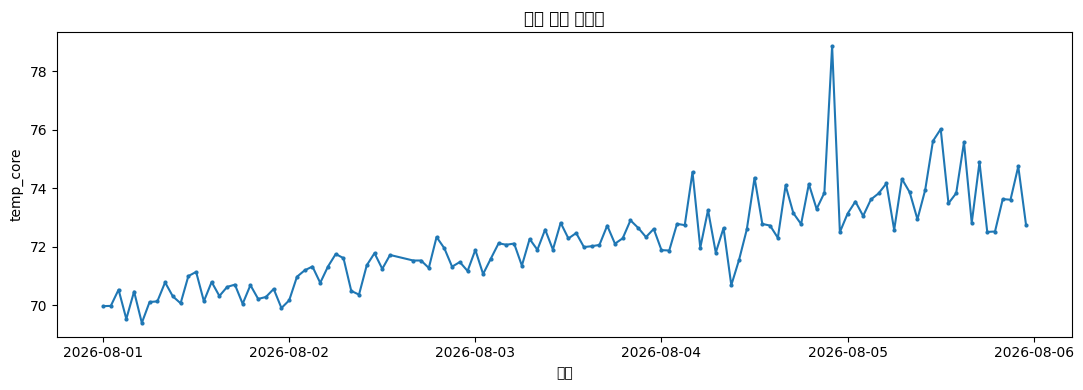

In [ ]:
plt.figure(figsize=(11,4))
plt.plot(demo_ts["timestamp"], demo_ts["temp_core"], marker=".", markersize=4)
plt.title("합성 온도 시계열")
plt.xlabel("시간")
plt.ylabel("temp_core")
plt.tight_layout()
plt.show()

### 🔍 무엇을 봐야 하나?
- 전체 방향: 값이 한쪽으로 이동하는가?
- 흔들림 폭: 후반에 커지는가?
- 스파이크: 주변과 비교해 한 점만 크게 튀는가?
- 누락: 시간 간격이 갑자기 벌어진 구간이 있는가?

선이 이어져 보여도 실제 timestamp가 빠졌을 수 있으므로 **그래프만으로 누락 여부를 판단하지 않습니다.**

## 36-2. 실제 시간 간격을 숫자로 확인

In [ ]:
ordered = demo_ts.sort_values("timestamp").copy()
gap = ordered["timestamp"].diff()

print("가장 흔한 간격:")
print(gap.value_counts().head())
print("\n가장 긴 간격:", gap.max())

가장 흔한 간격:
timestamp
0 days 01:00:00    116
0 days 03:00:00      1
Name: count, dtype: int64

가장 긴 간격: 0 days 03:00:00


정상 주기가 1시간인데 3시간 같은 간격이 나타나면 누락·수집 중단 등을 점검할 필요가 있습니다.

`sort_values()`는 **순서만 정렬**하지 빠진 시간을 복원하지는 않습니다.

## 36-3. DatetimeIndex + `.loc[]` — 의심 구간 좁혀 보기

In [ ]:
ts = ordered.set_index("timestamp").sort_index()

print("인덱스 자료형:", type(ts.index).__name__)

one_day = ts.loc["2026-08-02"]
period = ts.loc["2026-08-02":"2026-08-03"]

print("8월 2일 행 수:", len(one_day))
print("8월 2~3일 행 수:", len(period))

인덱스 자료형: DatetimeIndex
8월 2일 행 수: 22
8월 2~3일 행 수: 46


### `.loc`이 잘 맞는 상황
- 고장 발생일 전후만 자세히 보기
- 특정 기간 비교
- 전체를 훑고 의심 구간만 집중 분석

```text
전체 확인 → 의심 구간 발견 → .loc로 좁히기
```

## 36-4. `resample()` — 평균과 최대는 질문이 다르다

,mean,max
timestamp,,
2026-08-01 00:00:00,69.986717,70.538809
2026-08-01 06:00:00,70.405168,71.003160
2026-08-01 12:00:00,70.626386,71.144946
2026-08-01 18:00:00,70.289656,70.693802
2026-08-02 00:00:00,70.963860,71.328729
2026-08-02 06:00:00,71.232177,71.785017
2026-08-02 12:00:00,71.510194,71.723655
2026-08-02 18:00:00,71.591852,72.335527
2026-08-03 00:00:00,71.812573,72.121289


/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/2100351958.py:11: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tigh

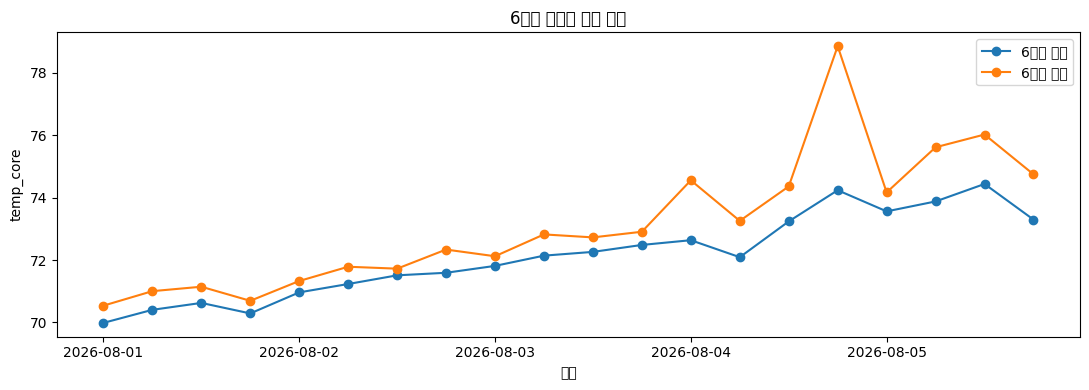

In [ ]:
six = ts["temp_core"].resample("6h").agg(["mean","max"])
display(six.head(10))

plt.figure(figsize=(11,4))
plt.plot(six.index, six["mean"], marker="o", label="6시간 평균")
plt.plot(six.index, six["max"], marker="o", label="6시간 최대")
plt.title("6시간 평균과 최대 비교")
plt.xlabel("시간")
plt.ylabel("temp_core")
plt.legend()
plt.tight_layout()
plt.show()

### 🔍 평균과 최대를 같이 보는 이유
- 평균과 최대가 함께 상승 → 전체 수준 상승 가능
- 평균은 비슷하지만 최대만 튐 → 짧은 피크 가능
- 너무 큰 단위 평균 → 순간 이상이 묻힐 수 있음

**장기 추세는 평균**, **순간 위험은 최대도 함께** 보는 방식이 유용할 수 있습니다.

## 36-5. `asfreq()` — 숨은 누락 시점 드러내기

In [ ]:
hourly = ts.asfreq("h")

print("정규화 전 행 수:", len(ts))
print("1시간 격자 행 수:", len(hourly))
print("결측 개수:", int(hourly["temp_core"].isna().sum()))
print("결측 시각:", list(hourly.index[hourly["temp_core"].isna()]))

정규화 전 행 수: 118
1시간 격자 행 수: 120
결측 개수: 2
결측 시각: [Timestamp('2026-08-02 14:00:00'), Timestamp('2026-08-02 15:00:00')]


`asfreq()` 후 NaN이 생긴 것은 에러가 아니라 **원래 측정되지 않았던 시간 칸이 드러난 것**입니다.

채울지 남길지는 센서 성격과 공백 길이를 보고 결정해야 합니다.

/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1020/38178610.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

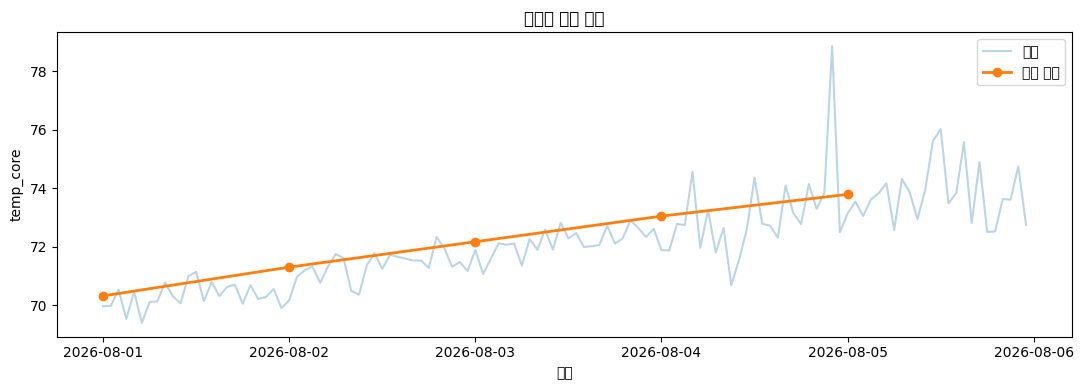

In [ ]:
daily = ts["temp_core"].resample("D").mean()

plt.figure(figsize=(11,4))
plt.plot(ts.index, ts["temp_core"], alpha=0.3, label="원본")
plt.plot(daily.index, daily, marker="o", linewidth=2, label="일별 평균")
plt.title("원본과 일별 평균")
plt.xlabel("시간")
plt.ylabel("temp_core")
plt.legend()
plt.tight_layout()
plt.show()

### 원본 vs 집계
- **원본:** 스파이크·실제 흔들림·짧은 이벤트
- **집계:** 큰 추세·장기 수준 변화

둘 중 하나가 무조건 더 좋은 것이 아니라 **질문이 다릅니다.**

## 36-6. cycle vs timestamp — 상황별 선택

| 질문 | 더 적합한 방식 |
|---|---|
| 몇 번째 작동에서 변했나? | cycle |
| 수명 진행 추세 | cycle + rolling |
| 어느 날짜에 이상이 있었나? | timestamp |
| 하루 평균 / 6시간 최대 | timestamp + resample |
| 특정 날짜만 보기 | timestamp + `.loc[]` |

### 매우 중요한 주의
C-MAPSS cycle에 학습용으로 `1 cycle = 1시간` 같은 가상 시간을 붙일 수는 있지만, 그것을 **실제 측정 날짜·시각**으로 해석하면 안 됩니다.

## 36-7. 상황별 시계열 코드 선택표

| 상황 | 추천 코드 | 이유 |
|---|---|---|
| 날짜 문자열 | `pd.to_datetime()` | 시간 연산 |
| 변환 오류 포함 | `errors="coerce"` | 잘못된 값 찾기 |
| 시간순 정렬 | `sort_index()` | 올바른 흐름 |
| 날짜/기간 선택 | `.loc[]` | 구간 집중 |
| 실제 간격 진단 | `index.to_series().diff()` | 누락·불규칙 탐지 |
| 규칙적 시간 격자 | `.asfreq()` | 빠진 시점 표시 |
| 큰 단위 평균 | `.resample().mean()` | 장기 추세 |
| 최대 피크 | `.resample().max()` | 위험 순간 |
| 시간대 특징 | `.dt.hour` | 시간대 분석 |
| 장기 추세 | `rolling().mean()` | 노이즈 완화 |

## 36-8. 시계열 그래프에서 자주 하는 오해

1. 선이 이어졌다고 **시간이 연속인 것은 아님**  
2. 크게 흔들려 보여도 **y축 범위가 좁을 수 있음**  
3. `resample().mean()`이 항상 정답은 아님 — 피크가 중요하면 `max()`/원본 확인  
4. 여러 설비를 한 선으로 이어 붙이면 **가짜 급변** 가능  
5. cycle은 작동 순서이지 실제 달력 시간이 아님

## 36-9. 최종 해석 공식

```text
축 확인
→ 전체 방향
→ 흔들림 크기
→ 급격한 튐
→ 누락 시간
→ 언제부터 달라졌는지
```

바로 “고장”이라고 결론 내리기보다:

> **관찰된 사실 → 이상 후보 → 추가 확인**

순서로 보는 것이 안전합니다.